Install Libraries


In [1]:
!pip install pandas numpy matplotlib seaborn scikit-learn


Create Synthetic Retail Dataset



In [2]:
import pandas as pd
import numpy as np

np.random.seed(42)

dates = pd.date_range(start="2022-01-01", periods=365)
data = []

for store in range(1, 4):
    for item in range(1, 6):
        base = np.random.randint(20, 50)
        for d in dates:
            seasonality = 10 * np.sin(2 * np.pi * d.dayofyear / 365)
            noise = np.random.normal(0, 5)
            sales = max(0, int(base + seasonality + noise))

            data.append([store, item, d, sales])

df = pd.DataFrame(data, columns=["store_id", "item_id", "date", "sales"])
df.head()

,store_id,item_id,date,sales
0,1,1,2022-01-01,23
1,1,1,2022-01-02,28
2,1,1,2022-01-03,28
3,1,1,2022-01-04,33
4,1,1,2022-01-05,22


Basic EDA

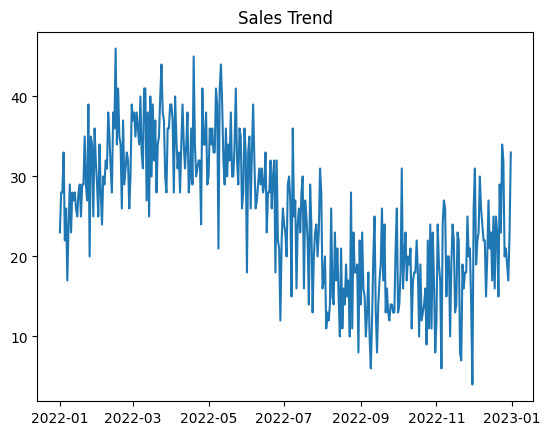

In [3]:
import matplotlib.pyplot as plt

sample = df[(df["store_id"]==1) & (df["item_id"]==1)]

plt.figure()
plt.plot(sample["date"], sample["sales"])
plt.title("Sales Trend")
plt.show()

Feature Engineering

In [4]:
df = df.sort_values("date")

df["lag_1"] = df.groupby(["store_id","item_id"])["sales"].shift(1)
df["lag_7"] = df.groupby(["store_id","item_id"])["sales"].shift(7)

df["rolling_mean_7"] = df.groupby(["store_id","item_id"])["sales"].shift(1).rolling(7).mean()

df = df.dropna()
df.head()

,store_id,item_id,date,sales,lag_1,lag_7,rolling_mean_7
5117,3,5,2022-01-08,34,46.0,39.0,33.857143
372,1,2,2022-01-08,38,35.0,29.0,34.428571
3292,2,5,2022-01-08,36,42.0,31.0,35.000000
1102,1,4,2022-01-08,34,36.0,26.0,34.571429
4752,3,4,2022-01-08,37,25.0,40.0,34.142857


Train Forecasting Model

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

features = ["lag_1", "lag_7", "rolling_mean_7"]
X = df[features]
y = df["sales"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

model = RandomForestRegressor(n_estimators=100)
model.fit(X_train, y_train)

preds = model.predict(X_test)

Evaluate Model

In [6]:
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(y_test, preds)
print("MAE:", mae)

MAE: 5.453361510153409


Plot Predictions

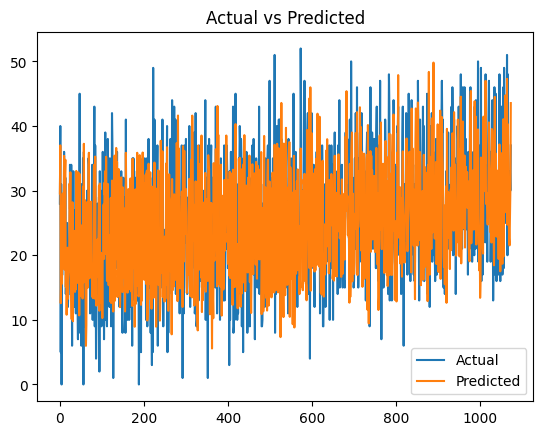

In [7]:
plt.figure()
plt.plot(y_test.values, label="Actual")
plt.plot(preds, label="Predicted")
plt.legend()
plt.title("Actual vs Predicted")
plt.show()

Inventory Optimization Logic

In [8]:
from scipy.stats import norm

def inventory_policy(forecast, lead_time=7, service_level=0.95, std_dev=10, on_hand=100):

    z = norm.ppf(service_level)

    demand_lead_time = sum(forecast[:lead_time])
    safety_stock = z * std_dev * (lead_time ** 0.5)

    reorder_point = demand_lead_time + safety_stock

    order_qty = max(0, reorder_point - on_hand)

    return {
        "Reorder Point": reorder_point,
        "Safety Stock": safety_stock,
        "Order Quantity": order_qty
    }

# Example
forecast = preds[:30]
inventory_policy(forecast)

{'Reorder Point': np.float64(196.1920697334954),
 'Safety Stock': np.float64(43.51873640016205),
 'Order Quantity': np.float64(96.1920697334954)}

Output Recommendation Table

In [9]:
result = inventory_policy(preds[:30])

for k,v in result.items():
    print(k, ":", round(v,2))

Reorder Point : 196.19
Safety Stock : 43.52
Order Quantity : 96.19


Install Streamlit

In [10]:
pip install streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 58.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 97.9 MB/s eta 0:00:00


app.py

2026-04-18 10:03:07.425 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-18 10:03:07.598 
  command:

    streamlit run /usr/local/lib/python3.12/dist-packages/colab_kernel_launcher.py [ARGUMENTS]
2026-04-18 10:03:07.599 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-18 10:03:07.599 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-18 10:03:07.601 No runtime found, using MemoryCacheStorageManager
2026-04-18 10:03:07.603 No runtime found, using MemoryCacheStorageManager
2026-04-18 10:03:07.604 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-18 10:03:07.645 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-18 10:03:07.646 T

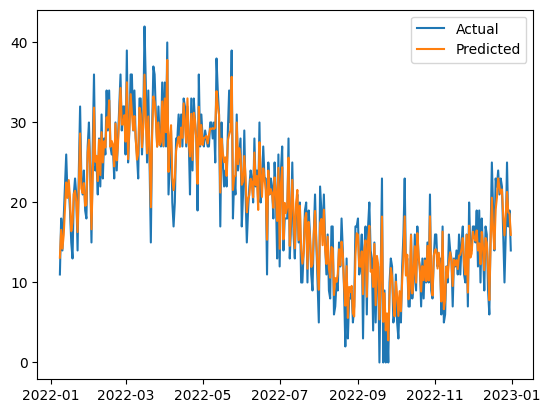

In [11]:
import streamlit as st
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from scipy.stats import norm

st.title("📦 Retail Forecasting & Inventory Dashboard")

# -----------------------------
# Load / Generate Data
# -----------------------------
@st.cache_data
def load_data():
    dates = pd.date_range(start="2022-01-01", periods=365)
    data = []

    for store in range(1, 4):
        for item in range(1, 6):
            base = np.random.randint(20, 50)
            for d in dates:
                seasonality = 10 * np.sin(2 * np.pi * d.dayofyear / 365)
                noise = np.random.normal(0, 5)
                sales = max(0, int(base + seasonality + noise))
                data.append([store, item, d, sales])

    df = pd.DataFrame(data, columns=["store_id", "item_id", "date", "sales"])
    return df

df = load_data()

# -----------------------------
# Sidebar Filters
# -----------------------------
store = st.sidebar.selectbox("Select Store", df["store_id"].unique())
item = st.sidebar.selectbox("Select Item", df["item_id"].unique())

filtered = df[(df["store_id"]==store) & (df["item_id"]==item)]

# -----------------------------
# Feature Engineering
# -----------------------------
filtered = filtered.sort_values("date")
filtered["lag_1"] = filtered["sales"].shift(1)
filtered["lag_7"] = filtered["sales"].shift(7)
filtered["rolling_mean_7"] = filtered["sales"].shift(1).rolling(7).mean()
filtered = filtered.dropna()

# -----------------------------
# Train Model
# -----------------------------
features = ["lag_1", "lag_7", "rolling_mean_7"]
X = filtered[features]
y = filtered["sales"]

model = RandomForestRegressor(n_estimators=100)
model.fit(X, y)

filtered["prediction"] = model.predict(X)

# -----------------------------
# Plot Forecast
# -----------------------------
st.subheader("📈 Sales Forecast")

fig, ax = plt.subplots()
ax.plot(filtered["date"], filtered["sales"], label="Actual")
ax.plot(filtered["date"], filtered["prediction"], label="Predicted")
ax.legend()
st.pyplot(fig)

# -----------------------------
# Inventory Inputs
# -----------------------------
st.subheader("📦 Inventory Optimization")

lead_time = st.slider("Lead Time (days)", 1, 30, 7)
service_level = st.slider("Service Level", 0.80, 0.99, 0.95)
on_hand = st.number_input("Current Stock", 0, 500, 100)

# -----------------------------
# Inventory Logic
# -----------------------------
forecast = filtered["prediction"].values[-30:]
std_dev = np.std(filtered["sales"] - filtered["prediction"])

z = norm.ppf(service_level)
demand_lt = sum(forecast[:lead_time])
safety_stock = z * std_dev * (lead_time ** 0.5)
rop = demand_lt + safety_stock
order_qty = max(0, rop - on_hand)

# -----------------------------
# Results
# -----------------------------
st.write("### 📊 Inventory Recommendation")
st.write(f"**Safety Stock:** {round(safety_stock,2)}")
st.write(f"**Reorder Point:** {round(rop,2)}")
st.write(f"**Recommended Order Quantity:** {round(order_qty,2)}")